In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

iris = load_iris()
features = iris['data']
labels = iris['target']
class_names = iris['target_names']
feature_names = iris['feature_names']

print(f"Features: {feature_names}, Classes: {class_names}")

df = pd.DataFrame(features,columns=feature_names).join(pd.DataFrame(labels,columns=['Label']))
df

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'], Classes: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [2]:
min_vals = np.min(features, axis=0)
max_vals = np.max(features, axis=0)
features_norm = (features - min_vals) / (max_vals - min_vals)
n_values = np.max(labels) + 1
labels_onehot = np.eye(n_values)[labels]
labels_onehot.shape

(150, 3)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(features_norm, labels_onehot, test_size=0.2, random_state=0)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((120, 4), (30, 4), (120, 3), (30, 3))

In [4]:
model = keras.Sequential([
    keras.layers.Dense(10, activation='relu', input_shape=(4,)),  # 4 = antall features
    keras.layers.Dense(3, activation='softmax')   # 3 = antall klasser
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # fordi labels er one-hot
    metrics=['accuracy']
)

history = model.fit(X_train, y_train, epochs=100, validation_split=0.2)

Epoch 1/100


c:\Users\jsand\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.3438 - loss: 1.2106 - val_accuracy: 0.2500 - val_loss: 1.3181
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3438 - loss: 1.1921 - val_accuracy: 0.2500 - val_loss: 1.3000
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3438 - loss: 1.1766 - val_accuracy: 0.2500 - val_loss: 1.2826
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3438 - loss: 1.1608 - val_accuracy: 0.2500 - val_loss: 1.2656
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3438 - loss: 1.1461 - val_accuracy: 0.2500 - val_loss: 1.2494
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3438 - loss: 1.1330 - val_accuracy: 0.2500 - val_loss: 1.2337
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3438 - loss: 1.1193 - val_accuracy: 0.2500 - val_loss: 1.2188
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3333 - loss: 1.1057 - val_accuracy: 0.2500 - val_loss: 1.2044
Epo

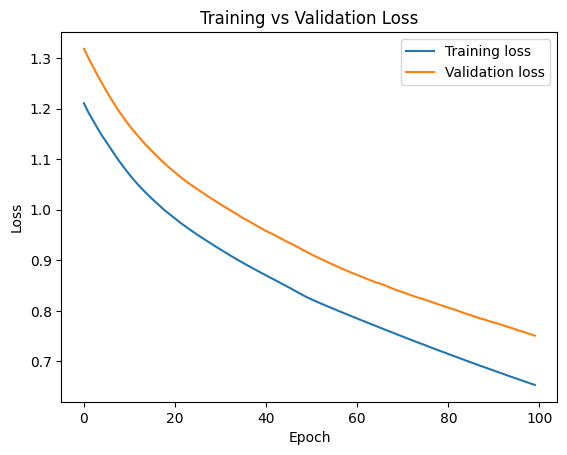

In [ ]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [7]:
loss_all, accuracy_all = model.evaluate(features_norm, labels_onehot)
print(f"Accuracy på hele datasettet: {accuracy_all:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6867 - loss: 0.6866 
Accuracy på hele datasettet: 0.6867
